In [1]:
import os
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/'
os.makedirs(foldername, exist_ok=True)

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import pandas as pd
import numpy as np
from forecasts.forecast_utils import get_forecast_params

# ═══════════════════════════════════════════════════════════════════
#  FORECAST PARAMETERS — only change start_date to switch forecasts
#  Supported range: Sep 2012 – Jul 2013 (1st of month)
# ═══════════════════════════════════════════════════════════════════
start_date = pd.Timestamp('2013-01-01')

# TPOSE-Vel state estimate directory (varies by run; set manually for each forecast)
vel_estimate_data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'

p = get_forecast_params(start_date)

# ── Unpack for use in subsequent cells ───────────────────────────
start_date  = p.start_date
end_date    = p.end_date
month_str   = p.month_str
day_str     = p.day_str
year_str    = p.year_str

noTAO_data_dir          = p.noTAO_data_dir
noTAO_forecast_data_dir = p.noTAO_forecast_data_dir
vel_forecast_data_dir   = p.vel_forecast_data_dir
grid_dir                = p.grid_dir

ref_date        = p.ref_date
itPerFile       = p.itPerFile
delta_t         = p.delta_t
num_diags       = p.num_diags
intervals       = p.intervals
n_forecast_days = p.n_forecast_days
n_eval          = p.n_eval
eval_slice      = p.eval_slice
eval_start_date = p.eval_start_date
days            = p.days
eval_dates      = p.eval_dates
eval_months     = p.eval_months
month_bounds    = p.month_bounds
month_centers   = p.month_centers

print(f'Forecast     : {start_date.date()} → {end_date.date()} ({n_forecast_days} days)')
print(f'itPerFile    : {itPerFile}  |  delta_t: {delta_t:.0f} s')
print(f'noTAO est dir: {noTAO_data_dir}')
print(f'noTAO fct dir: {noTAO_forecast_data_dir}')
print(f'Vel est dir  : {vel_estimate_data_dir}')
print(f'Vel fct dir  : {vel_forecast_data_dir}')

Forecast     : 2013-01-01 → 2013-04-30 (119 days)
itPerFile    : 72  |  delta_t: 1200 s
noTAO est dir: /data/SO3/averdy/TPOSE6/jan2013/diags_daily/
noTAO fct dir: /data/SO3/edavenport/tpose6/forecasts/jan012013_tpose_noVel/
Vel est dir  : /data/SO3/edavenport/tpose6/jan2013/run_iter14/
Vel fct dir  : /data/SO3/edavenport/tpose6/forecasts/jan012013/


### Load TPOSE Estimates and Forecasts

In [3]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14

prefix = ['diag_state']

def open_tpose(data_dir):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=grid_dir,
        iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=delta_t)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds

ds_tpose_noTAO          = open_tpose(noTAO_data_dir)
ds_tpose_noTAO_forecast = open_tpose(noTAO_forecast_data_dir)
ds_tpose_vel            = open_tpose(vel_estimate_data_dir)
ds_tpose_vel_forecast   = open_tpose(vel_forecast_data_dir)

### Load GLORYS Reanalysis

In [4]:
from forecasts.forecast_utils import load_hycom_daily

glorys = xr.open_mfdataset('/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc', combine='by_coords')
hycom  = load_hycom_daily(start_date, end_date)   # None if no files exist for this window

glorys_wind = glorys[['uo', 'vo']].sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(-5, 5)
)
if hycom is not None:
    hycom_wind = hycom[['water_u', 'water_v']].sel(lat=slice(-5, 5))

if hycom is None:
    print('WARNING: No HYCOM data available for this forecast window — HYCOM will be omitted from figures.')

### Load and Daily-Average TAO ADCP Data

In [5]:
adcp = xr.open_dataset('/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc')

raw_dates = pd.to_datetime(
    adcp.prof_YYYYMMDD.values.astype(int).astype(str), format='%Y%m%d'
)

u_raw = adcp.prof_U.values.copy().astype(float)
v_raw = adcp.prof_V.values.copy().astype(float)
u_raw[u_raw == -9999.] = np.nan
v_raw[v_raw == -9999.] = np.nan

adcp_lons   = adcp.prof_lon.values
adcp_depths = adcp.prof_depth.values   # (62,) positive downward

tao_lons       = np.array([190., 220., 250.])
tao_loc_labels = ['170W', '140W', '110W']

eval_dates = pd.date_range(start_date, periods=n_eval)
tao_u = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)
tao_v = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)

for i, d in enumerate(eval_dates):
    for j, lon in enumerate(tao_lons):
        mask = (raw_dates == d) & (adcp_lons == lon)
        if mask.sum() > 0:
            tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
            tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)

print(f'TAO obs shape: {tao_u.shape}  (time, location, depth)')
print(f'ADCP depth range: {adcp_depths[0]}–{adcp_depths[-1]} m')

TAO obs shape: (119, 3, 62)  (time, location, depth)
ADCP depth range: 10.0–315.0 m


/tmp/ipykernel_92257/3364031931.py:26: RuntimeWarning: Mean of empty slice
  tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
/tmp/ipykernel_92257/3364031931.py:27: RuntimeWarning: Mean of empty slice
  tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)


### Load TAO Climatology and Compute Baseline Std per Location

For each forecast day, look up the climatological monthly std profile at the matching month and location, then collapse to a scalar via
RMS over depth:  σ_clim = sqrt(mean_z[σ(z)²])
This matches the norm used by per-location RMSE (mean over depth of squared errors).

In [6]:
# Load and interpolate climatology MEAN profiles to ADCP depths for each location
adcp_depth_da = xr.DataArray(adcp_depths, dims='depth')

clim_u_mean = np.full((len(tao_lons), 12, len(adcp_depths)), np.nan)  # (loc, month, depth)
clim_v_mean = np.full((len(tao_lons), 12, len(adcp_depths)), np.nan)

for j, loc_label in enumerate(tao_loc_labels):
    ds_c = xr.open_dataset(f'tao_data/tao_clim_{loc_label}_1993to2012.nc')
    clim_u_mean[j] = ds_c.u_mean.interp(depth=adcp_depth_da, method='linear').values
    clim_v_mean[j] = ds_c.v_mean.interp(depth=adcp_depth_da, method='linear').values

# Build (time, location, depth) climatological mean forecast for each day
clim_forecast_u = np.full_like(tao_u, np.nan)   # (time, location, depth)
clim_forecast_v = np.full_like(tao_v, np.nan)

for t, d in enumerate(eval_dates):
    m = d.month - 1   # 0-indexed
    clim_forecast_u[t] = clim_u_mean[:, m, :]
    clim_forecast_v[t] = clim_v_mean[:, m, :]

print('Climatology forecast arrays built. Shape:', clim_forecast_u.shape)

Climatology forecast arrays built. Shape: (119, 3, 62)


### Interpolate Models to TAO Locations and Compute Per-Location RMSE

In [7]:
interp_depths     = adcp_depths
neg_interp_depths = -interp_depths

def extract_tpose_vel(ds):
    ds = ds.isel(time=eval_slice)
    loc_da   = xr.DataArray(tao_lons,          dims='location')
    depth_da = xr.DataArray(neg_interp_depths, dims='depth')

    u = (ds.UVEL
           .sel(YC=0.0, method='nearest')
           .interp(XG=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute())
    v = (ds.VVEL
           .sel(YG=0.0, method='nearest')
           .interp(XC=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute())
    return u.values, v.values

print('Extracting TPOSE-noVel state estimate...')
noTAO_u,     noTAO_v     = extract_tpose_vel(ds_tpose_noTAO)
print('Extracting TPOSE-noVel forecast...')
noTAO_fct_u, noTAO_fct_v = extract_tpose_vel(ds_tpose_noTAO_forecast)
print('Extracting TPOSE-Vel state estimate...')
vel_est_u,   vel_est_v   = extract_tpose_vel(ds_tpose_vel)
print('Extracting TPOSE-Vel forecast...')
vel_fct_u,   vel_fct_v   = extract_tpose_vel(ds_tpose_vel_forecast)
print('Done.')

tao_lons_neg = tao_lons - 360
loc_da_g   = xr.DataArray(tao_lons_neg, dims='location')
depth_da_g = xr.DataArray(interp_depths, dims='depth')

glorys_u = (glorys_wind.uo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

glorys_v = (glorys_wind.vo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

print('GLORYS extracted. Shape:', glorys_u.shape)

if hycom is not None:
    loc_da_h   = xr.DataArray(tao_lons_neg, dims='location')
    depth_da_h = xr.DataArray(interp_depths, dims='depth')
    hycom_u = (hycom_wind.water_u
                 .sel(lat=0.0, method='nearest')
                 .interp(lon=loc_da_h, depth=depth_da_h, method='linear')
                 .transpose('time', 'location', 'depth')
                 .isel(time=eval_slice)
                 .compute()).values
    hycom_v = (hycom_wind.water_v
                 .sel(lat=0.0, method='nearest')
                 .interp(lon=loc_da_h, depth=depth_da_h, method='linear')
                 .transpose('time', 'location', 'depth')
                 .isel(time=eval_slice)
                 .compute()).values
    print('HYCOM extracted. Shape:', hycom_u.shape)

# ── Per-location RMSE: returns (time, location) ──────────────────
def per_loc_rmse(model, obs):
    """RMS over valid depths at each (time, location).
    model, obs: (time, location, depth)
    returns:    (time, location)
    """
    diff = model - obs
    n_valid = np.sum(np.isfinite(diff), axis=2)
    return np.sqrt(np.nansum(diff ** 2, axis=2) / np.maximum(n_valid, 1))

def persistence_per_loc_rmse(model_arr, obs_arr):
    field = model_arr[0:1, :, :]
    return per_loc_rmse(np.broadcast_to(field, model_arr.shape), obs_arr)

rmse_noTAO_u          = per_loc_rmse(noTAO_u,     tao_u)
rmse_noTAO_fct_u      = per_loc_rmse(noTAO_fct_u, tao_u)
rmse_vel_est_u        = per_loc_rmse(vel_est_u,   tao_u)
rmse_vel_fct_u        = per_loc_rmse(vel_fct_u,   tao_u)
rmse_glorys_u         = per_loc_rmse(glorys_u,    tao_u)
rmse_noTAO_fct_pers_u = persistence_per_loc_rmse(noTAO_fct_u, tao_u)
rmse_vel_fct_pers_u   = persistence_per_loc_rmse(vel_fct_u,   tao_u)

rmse_noTAO_v          = per_loc_rmse(noTAO_v,     tao_v)
rmse_noTAO_fct_v      = per_loc_rmse(noTAO_fct_v, tao_v)
rmse_vel_est_v        = per_loc_rmse(vel_est_v,   tao_v)
rmse_vel_fct_v        = per_loc_rmse(vel_fct_v,   tao_v)
rmse_glorys_v         = per_loc_rmse(glorys_v,    tao_v)
rmse_noTAO_fct_pers_v = persistence_per_loc_rmse(noTAO_fct_v, tao_v)
rmse_vel_fct_pers_v   = persistence_per_loc_rmse(vel_fct_v,   tao_v)

if hycom is not None:
    rmse_hycom_u = per_loc_rmse(hycom_u, tao_u)
    rmse_hycom_v = per_loc_rmse(hycom_v, tao_v)

print('RMSE arrays shape (time, location):', rmse_vel_fct_u.shape)

Extracting TPOSE-noVel state estimate...


Extracting TPOSE-noVel forecast...


Extracting TPOSE-Vel state estimate...


Extracting TPOSE-Vel forecast...


Done.


GLORYS extracted. Shape: (119, 3, 62)


HYCOM extracted. Shape: (119, 3, 62)
RMSE arrays shape (time, location): (119, 3)


In [8]:
n_loc = len(tao_lons)

# Climatological RMSE: how wrong is the climatological mean against the actual forecast obs?
# Uses the same per_loc_rmse norm as the model comparisons — directly comparable.
clim_baseline_u = per_loc_rmse(clim_forecast_u, tao_u)   # (time, location)
clim_baseline_v = per_loc_rmse(clim_forecast_v, tao_v)

print('Climatology baseline shape:', clim_baseline_u.shape)
print('Sample U clim RMSE at 170W (first 5 days):', clim_baseline_u[:5, 0])

Climatology baseline shape: (119, 3)
Sample U clim RMSE at 170W (first 5 days): [0.19658613 0.20294471 0.18962622 0.19256467 0.20780861]


### Figures: Per-Location RMSE vs TAO ADCP with Climatology Baseline
Two figures (U and V), each with 3 rows (one per mooring location).
Each row: time-series RMSE (left) + IQR box (right).
Dashed grey line = climatological RMS-std baseline (σ_clim) for that location.

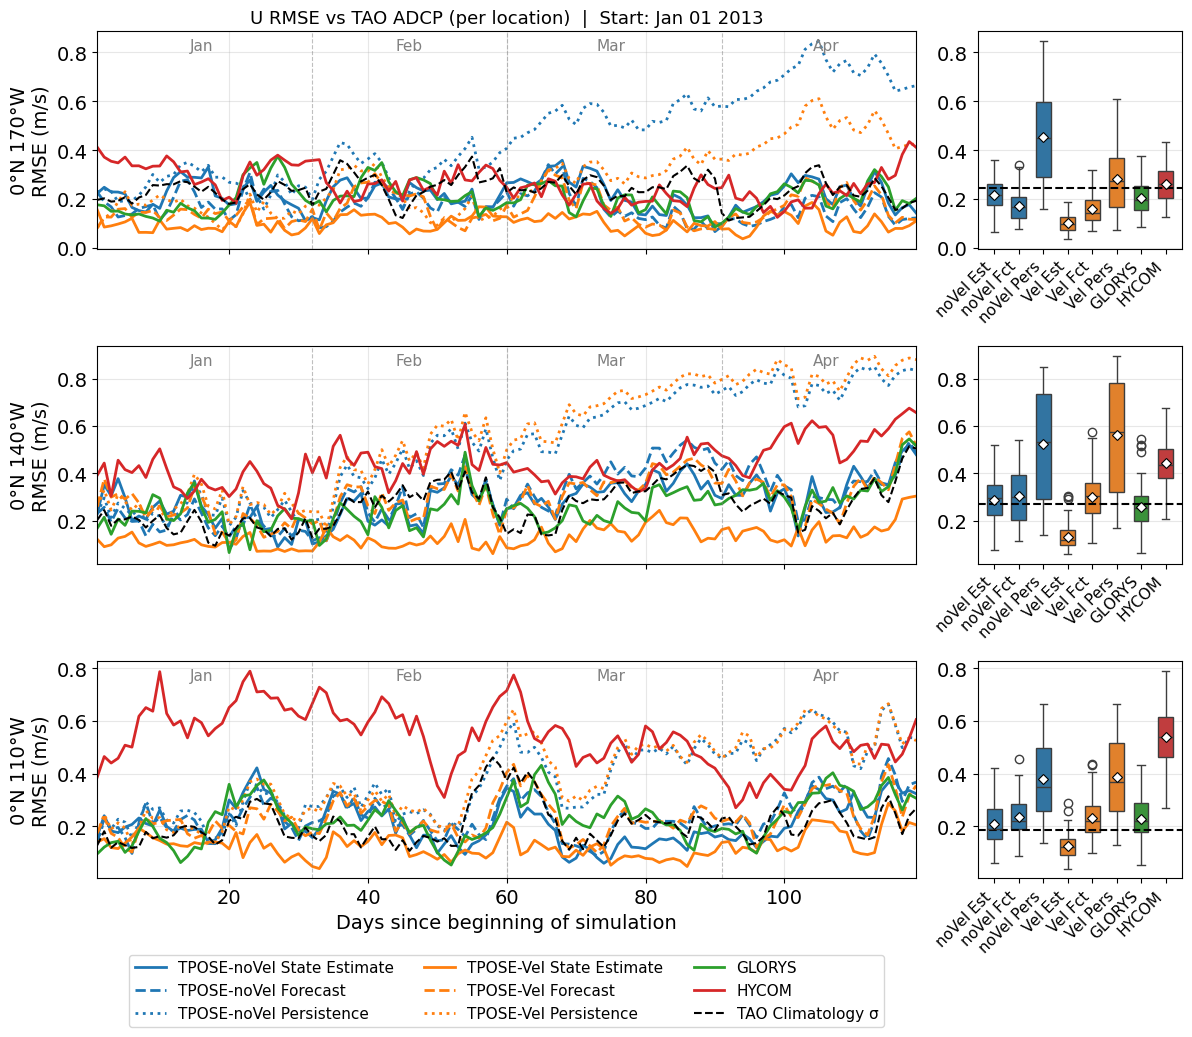

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/vel_u_rmse_per_loc_jan012013.png


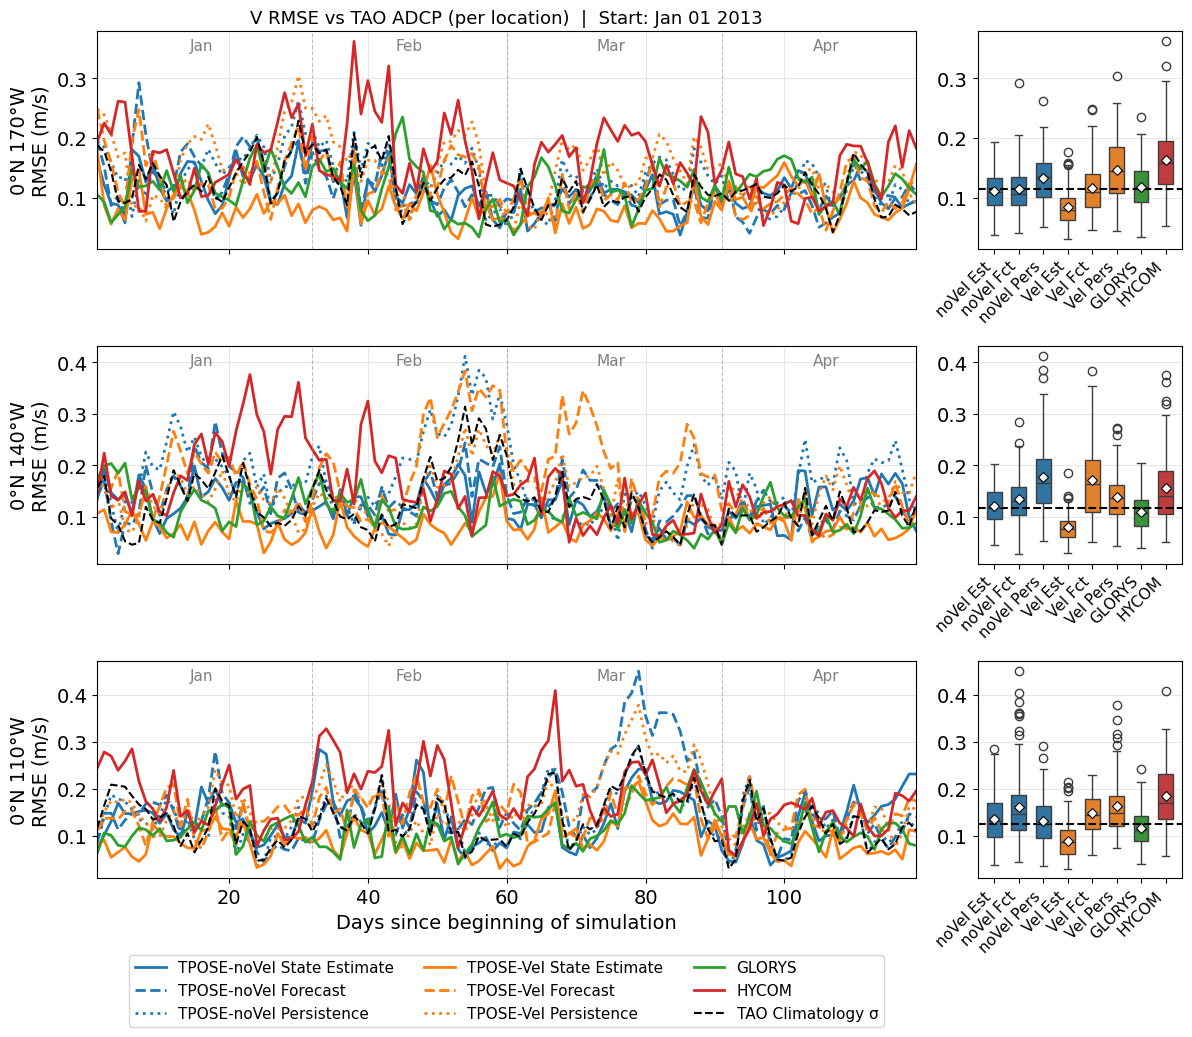

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/vel_v_rmse_per_loc_jan012013.png


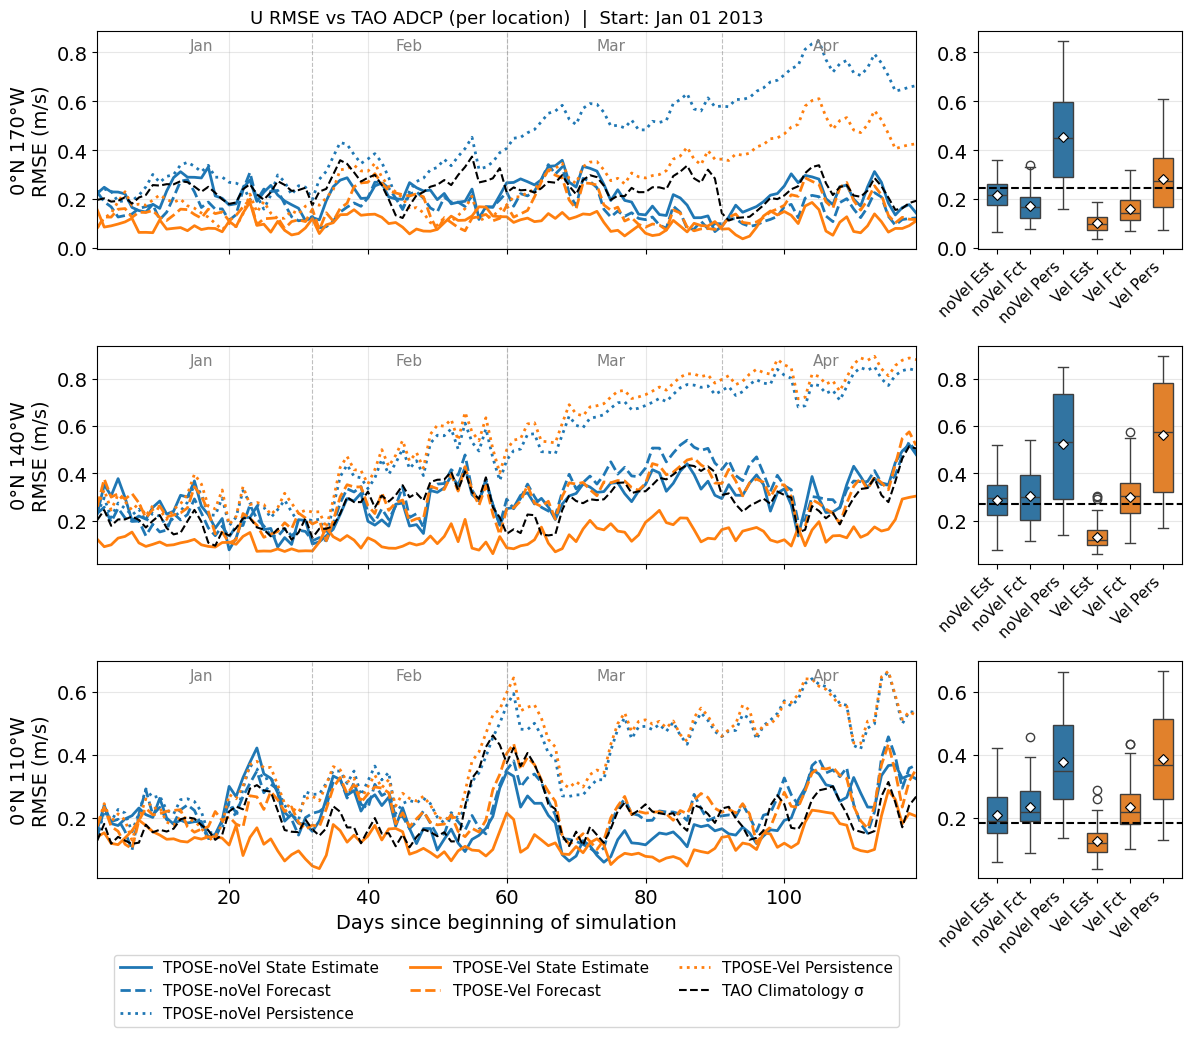

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/vel_u_rmse_per_loc_jan012013_tpose_only.png


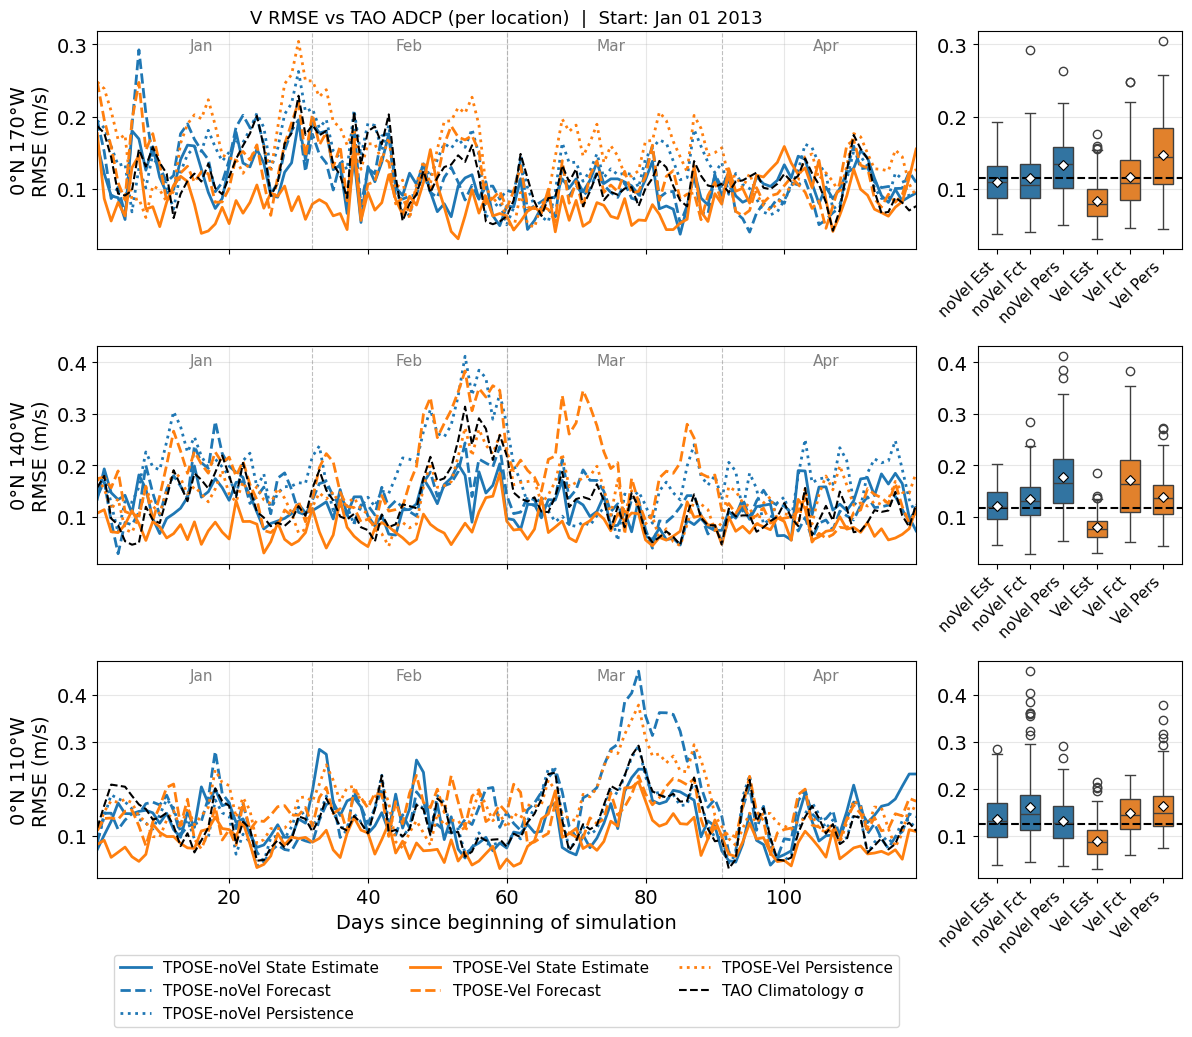

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/vel_v_rmse_per_loc_jan012013_tpose_only.png


In [9]:
import seaborn as sns
import matplotlib.gridspec as gridspec

loc_titles = ['0°N 170°W', '0°N 140°W', '0°N 110°W']

# Dataset registry: (u_rmse, v_rmse, long_label, short_label, color, linestyle)
# Each rmse array is (time, location); we index by location in the loop below.
datasets_all = [
    (rmse_noTAO_u,          rmse_noTAO_v,          'TPOSE-noVel State Estimate', 'noVel Est',  'C0', '-'),
    (rmse_noTAO_fct_u,      rmse_noTAO_fct_v,      'TPOSE-noVel Forecast',       'noVel Fct',  'C0', '--'),
    (rmse_noTAO_fct_pers_u, rmse_noTAO_fct_pers_v, 'TPOSE-noVel Persistence',    'noVel Pers', 'C0', ':'),
    (rmse_vel_est_u,        rmse_vel_est_v,         'TPOSE-Vel State Estimate',   'Vel Est',    'C1', '-'),
    (rmse_vel_fct_u,        rmse_vel_fct_v,         'TPOSE-Vel Forecast',         'Vel Fct',    'C1', '--'),
    (rmse_vel_fct_pers_u,   rmse_vel_fct_pers_v,    'TPOSE-Vel Persistence',      'Vel Pers',   'C1', ':'),
    (rmse_glorys_u,         rmse_glorys_v,           'GLORYS',                     'GLORYS',     'C2', '-'),
]
if hycom is not None:
    datasets_all.append((rmse_hycom_u, rmse_hycom_v, 'HYCOM', 'HYCOM', 'C3', '-'))

datasets_tpose = datasets_all[:6]


def make_per_loc_rmse_fig(datasets, clim_u, clim_v, uv_idx, component_name, suffix):
    """
    uv_idx: 0 for U, 1 for V
    clim_uv: (time, location) climatology baseline
    """
    clim = clim_u if uv_idx == 0 else clim_v
    short_names = [ds[3] for ds in datasets]
    palette     = [ds[4] for ds in datasets]

    fig = plt.figure(figsize=(14, 11))
    gs  = gridspec.GridSpec(3, 2, width_ratios=[4, 1], hspace=0.45, wspace=0.12)

    for row, (loc_idx, loc_title) in enumerate(zip(range(n_loc), loc_titles)):
        ax_ts = fig.add_subplot(gs[row, 0])
        ax_bx = fig.add_subplot(gs[row, 1])

        ts_data = [ds[uv_idx][:, loc_idx] for ds in datasets]

        # ── Time series ───────────────────────────────────────────
        for data, ds in zip(ts_data, datasets):
            ax_ts.plot(days, data, color=ds[4], lw=2, ls=ds[5],
                       label=ds[2] if row == 0 else None)

        # Climatology baseline (may step at month boundaries)
        ax_ts.plot(days, clim[:, loc_idx], color='k', lw=1.5,
                   ls='--', label='TAO Climatology σ' if row == 0 else None)

        for d in month_bounds.values():
            ax_ts.axvline(d, color='gray', lw=0.8, ls='--', alpha=0.5)
        ymax = ax_ts.get_ylim()[1]
        for mname, xpos in month_centers:
            ax_ts.text(xpos, ymax * 0.97, mname, ha='center', va='top',
                       color='gray', fontsize=11)

        ax_ts.set_ylabel(f'{loc_title}\nRMSE (m/s)')
        ax_ts.set_xlim(days[0], days[-1])
        ax_ts.grid(alpha=0.3)
        if row < 2:
            plt.setp(ax_ts.get_xticklabels(), visible=False)

        # ── IQR box ───────────────────────────────────────────────
        col_names = [f'ds{k}' for k in range(len(ts_data))]
        box_df    = pd.DataFrame({n: pd.Series(d) for n, d in zip(col_names, ts_data)})
        pal_dict  = dict(zip(col_names, palette))
        sns.boxplot(data=box_df, ax=ax_bx, palette=pal_dict, width=0.6)
        for k, d in enumerate(ts_data):
            ax_bx.plot(k, np.nanmean(d), marker='D', ms=5,
                       color='white', mec='black', mew=0.8, zorder=5)
        # Clim baseline: median over the forecast evaluation window (consistent with IQR box)
        ax_bx.axhline(np.nanmedian(clim[:, loc_idx]), color='k', lw=1.5,
                      ls='--', label='Climatology σ')
        ax_bx.set_xticks(range(len(short_names)))
        ax_bx.set_xticklabels(short_names, fontsize=11, rotation=45, ha='right')
        ax_bx.set_ylabel('')
        ax_bx.grid(alpha=0.3, axis='y')

    fig.axes[0].set_title(
        f'{component_name} RMSE vs TAO ADCP (per location)  |  Start: {start_date.strftime("%b %d %Y")}',
        fontsize=13
    )
    fig.axes[4].set_xlabel('Days since beginning of simulation')

    # Legend from row-0 axes
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.axes[4].legend(handles, labels, loc='upper center',
                       bbox_to_anchor=(0.5, -0.35), ncol=3, borderaxespad=0, fontsize=11)

    fname = foldername + f'vel_{component_name.lower()}_rmse_per_loc_{month_str}{day_str}{year_str}{suffix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


for datasets, suffix in [(datasets_all, ''), (datasets_tpose, '_tpose_only')]:
    make_per_loc_rmse_fig(datasets, clim_baseline_u, clim_baseline_v, 0, 'U', suffix)
    make_per_loc_rmse_fig(datasets, clim_baseline_u, clim_baseline_v, 1, 'V', suffix)